In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import root_scalar

# --- Global style settings ---
plt.rcParams.update({
    # Figure
    "figure.facecolor": "white",
    "figure.edgecolor": "black",

    # Axes
    "axes.linewidth": 1.2,         # outside box thickness
    "axes.edgecolor": "black",     # box color
    "axes.labelsize": 12,
    "axes.labelcolor": "black",
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.prop_cycle": plt.cycler("color", ["black"]),  # force black lines

    # Grid
    "grid.color": "0.7",           # light grey grid
    "grid.linestyle": "-",
    "grid.linewidth": 0.6,

    # Ticks
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # Lines
    "lines.linewidth": 2.5,        # thicker lines
    "lines.solid_capstyle": "round",

    # Font
    "text.usetex": True,           # use LaTeX for all text
    "font.family": "serif",

    # Legend
    "legend.frameon": False,
    "legend.fontsize": 11,
})

**Dividend Process and Dividend Growth**

Assume dividends follow
$$
\frac{D_t}{D_{t-1}} \;=\; a\,\varepsilon^D_t, 
\qquad \log \varepsilon^D_t \sim \mathcal{N}\!\left(-\tfrac{1}{2}s^2,\; s^2\right),
\quad \{\varepsilon^D_t\}\ \text{i.i.d.},\ a>0,\ s>0 $$

Given the lognormal property and $\mathbb{E}[\log \varepsilon^D_t]=-\tfrac{1}{2}s^2$ implies $\mathbb{E}[\varepsilon^D_t]=1$, so $a$ is the unconditional mean gross growth factor.

Aggregate consumtion evolves accordingly to 

$$
\frac{C_t}{C_{t-1}} \;=\; a\,\varepsilon^C_t, 
$$

where the log noise terms are jointly normal and $s^c = 1/7 s^d$ and the correlation is $0.2$.

In [7]:
# We now generate a dividend process according to the previous equation.

a = 1.01 #directly from the data
#for s we know that sqrt(a^2 * exp(s^2) - 1) = 2.88
var_D = 2.88**2
s_squared = np.log(var_D / a**2 + 1)
s = np.sqrt(s_squared)
#print(a, s, np.exp((s**2)/2))
#make sure a is less than exp(s^2/2)
s_dividend = np.sqrt(np.log(a) * 2) - 0.01 #slightly less than the upper bound
s_consumption = 1/7 * s_dividend 
print(a, s, np.exp((s**2)/2), np.exp((s_consumption**2)/2))
T = 2000
#generate bivariate normal shocks with correlation 0.2 and std dev s
mean = [0, 0]
rho_c = 0.2
cov = [[s_dividend**2, rho_c * s_dividend * s_consumption], 
       [rho_c * s_dividend * s_consumption, s_consumption**2]]
shocks = np.random.multivariate_normal(mean, cov, T)
epsilon_D = np.exp(shocks[:, 0])
epsilon_C = np.exp(shocks[:, 1])
D0 = 1
D = D0 * np.cumprod(a * epsilon_D)
C0 = 1
C = C0 * np.cumprod(a * epsilon_C)


1.01 1.4871690099115467 3.0217490882270095 1.0001753140147231


In [8]:
#check mean and var of net growth rate
growth_rates_D = D[1:] / D[:-1] - 1
growth_rates_C = C[1:] / C[:-1] - 1
print("Mean growth rate D:", np.mean(growth_rates_D))
print("Standard deviation of growth rate D:", np.std(growth_rates_D))
print("Mean growth rate C:", np.mean(growth_rates_C))
print("Standard deviation of growth rate C:", np.std(growth_rates_C))

#compare with theorical values
theoretical_mean = a - 1
theoretical_std = (a ** 2 * (np.exp(s ** 2) - 1)) ** 0.5
print("Theoretical mean growth rate:", theoretical_mean)
print("Theoretical standard deviation of growth rate:", theoretical_std)

Mean growth rate D: 0.01602902216069026
Standard deviation of growth rate D: 0.13338483644945764
Mean growth rate C: 0.01012057781872277
Standard deviation of growth rate C: 0.018924985777623582
Theoretical mean growth rate: 0.010000000000000009
Theoretical standard deviation of growth rate: 2.88


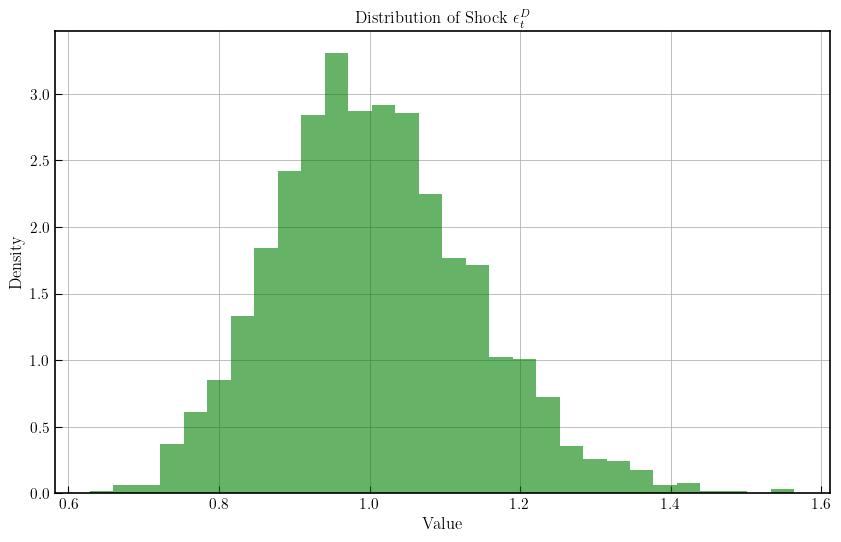

In [9]:
#Visualzie the distribution of epsilon_D
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(epsilon_D, bins=30, density=True, alpha=0.6, color='g')
ax.set_title('Distribution of Shock $\\epsilon^D_t$')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
plt.show()

In [10]:
# #plot the dividend growth rate
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(model.growth_rates, label='Growth Rates $g_t$', color='orange')
# ax.set_title('Simulated Dividend Growth Rates')
# ax.set_xlabel('Time $t$')
# ax.set_ylabel('Growth Rates $g_t$')
# ax.legend()
# plt.show()

In [11]:
#price
delta = 0.99
gamma = 5
rho_e = np.exp(gamma * (1 + gamma) * s_consumption**2 / 2) * np.exp( - gamma * rho_c * s_consumption * s_dividend)
k = (delta * a ** (1 - gamma) * rho_e) / (1 - delta * a ** (1 - gamma) * rho_e)
price = k * D

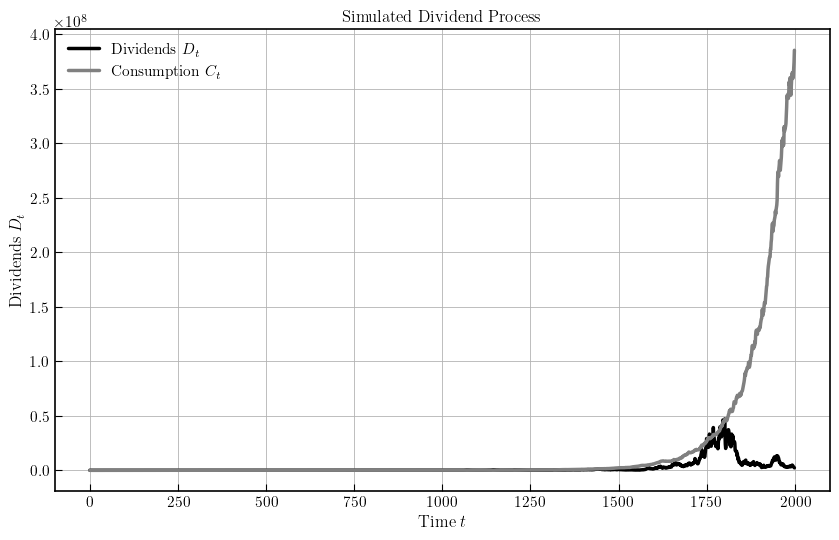

In [12]:
# Plot the dividend process
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(D, label='Dividends $D_t$')
#add consumption in grey
ax.plot(C, label='Consumption $C_t$', color='grey')
ax.set_title('Simulated Dividend Process')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Dividends $D_t$')
ax.legend()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_24139/2339032621.py:17: SyntaxWarning: invalid escape sequence '\m'
  ax.legend(['Fit results: $\mu$ = %.4f,  $\sigma$ = %.4f' % (mu, std)])


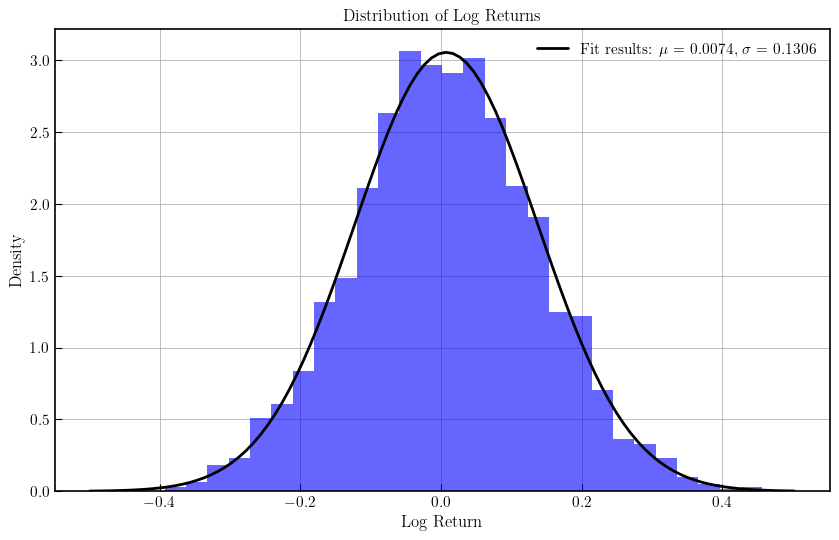

In [13]:
# in this setting prices are just a scaled version of dividends, since the price dividend ratio is constant.
#then log returns are log dividend growth and should be normally distributed, let's check it
log_returns = np.log(price[1:] / price[:-1])
#histogram
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(log_returns, bins=30, density=True, alpha=0.6, color='b')
ax.set_title('Distribution of Log Returns')
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
#overlay a normal distribution with same mean and std
from scipy.stats import norm
mu, std = norm.fit(log_returns)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.legend(['Fit results: $\mu$ = %.4f,  $\sigma$ = %.4f' % (mu, std)])
plt.show()

In [14]:
#shift dividends to get D_t-1
D_lag = np.empty_like(D)
D_lag[0] = np.nan
D_lag[1:] = D[:-1]


In [15]:
#Check the rationality of the solution
expected_price = k * a * D_lag
discrepancy = price - expected_price
theoretical_discrepancy = k * a * D_lag * (epsilon_D - 1)

#remove the first element which is nan
discrepancy = discrepancy[1:]
theoretical_discrepancy = theoretical_discrepancy[1:]

#check
np.allclose(discrepancy, theoretical_discrepancy)

True

In [16]:
#now let's generate a sunspot process
sigma_xi = 0.1
xi = np.exp(np.random.normal(- sigma_xi**2 / 2, sigma_xi, T))
B0 = 1
B = B0 * np.cumprod(xi)

#sunspot price 
sunspot_price = price + B

In [87]:
class Adam_Marcet_model:
    def __init__(self, parameters):
        self.a = parameters['a']
        self.s_dividend = parameters['s_dividend']
        self.s_consumption = parameters['s_consumption']
        self.rho_c = parameters['rho_c']
        self.delta = parameters['delta']
        self.gamma = parameters['gamma']
        self.alpha = parameters['alpha'] #gain parameter for learning (1/alpha) in the paper
        self.rho_e = np.exp(self.gamma * (1 + self.gamma) * self.s_consumption**2 / 2) * np.exp( - self.gamma * self.rho_c * self.s_consumption * self.s_dividend)
        self.seed = parameters.get('seed', None)
        if self.seed is not None:
            np.random.seed(self.seed)
        #bounds on beta
        self.beta_u =  (500 - self.delta * self.a ** (1 - self.gamma) * self.rho_e) / (500 * self.delta)
        self.beta_l = self.delta ** -1 - 2 * (self.delta ** -1 - self.beta_u)


        self.T = parameters['T']
        self.D0 = parameters['D0']
        self.C0 = parameters['C0']
        self.D, self.C = np.zeros(self.T), np.zeros(self.T)
        self.beta = np.zeros(self.T)
        
        self.price = np.zeros(self.T)
        self.REE_price = np.zeros(self.T)

        #since to obtain beta_t we need beta_t-1, C_t-1 C_t-2 P_t-1 and P_t-2, we initialize them at their RE steady state value
        self.beta_constant = self.a ** (1 - self.gamma) * self.rho_e
        self.beta_minus_1 = self.a ** (1 - self.gamma) * self.rho_e
        self.C_minus_2 = 1 #arbitrary initial value
        self.C_minus_1 = self.a * np.exp(self.s_consumption**2 /2) * self.C_minus_2 #mean growth rate of consumption
        self.D_minus_2 = 1 #arbitrary initial value
        self.D_minus_1 = self.a * np.exp(self.s_dividend**2 /2) * self.D_minus_2 #mean growth rate of dividends
        self.price_minus_2 = (self.delta * self.beta_minus_1) / (1 - self.delta * self.beta_minus_1) * self.D_minus_2
        self.price_minus_1 = (self.delta * self.beta_minus_1) / (1 - self.delta * self.beta_minus_1) * self.D_minus_1

        self.constant_price_dividend_ratio = (self.delta * self.beta_constant) / (1 - self.delta * self.beta_constant)

        #implied bounds on price dividend ratio
        self.pd_ratio_u = (self.delta * self.beta_constant) / (1 - self.delta * self.beta_u)
        self.pd_ratio_l = (self.delta * self.beta_constant) / (1 - self.delta * self.beta_l)

    def weighting_function(self, x):
        #weighting function to rescale beta within bounds
        if x <= self.beta_l:
            return x
        else:
            return self.beta_l + (x - self.beta_l) / (x + self.beta_u - 2 * self.beta_l) * (self.beta_u - self.beta_l)



    def generate_exogenous_processes(self):
        # we generate the bivariate normal shocks with correlation rho_c and std dev s
        mean = [-self.s_dividend**2/2, -self.s_consumption**2/2]
        cov = [[self.s_dividend**2, self.rho_c * self.s_dividend * self.s_consumption], 
               [self.rho_c * self.s_dividend * self.s_consumption, self.s_consumption**2]]
        shocks = np.random.multivariate_normal(mean, cov, self.T)
        epsilon_D = np.exp(shocks[:, 0])
        epsilon_C = np.exp(shocks[:, 1])
        
        self.D = self.D0 * np.cumprod(self.a * epsilon_D)
        self.C = self.C0 * np.cumprod(self.a * epsilon_C)

    def compute_endogenous_processes(self):
        for t in range(self.T):
            #first we update beta_t
            self.beta[t] = self.beta_minus_1 + (self.alpha) * ((self.C_minus_1 / self.C_minus_2) ** (-self.gamma) * (self.price_minus_1 / self.price_minus_2) - self.beta_minus_1)
            # we rescale beta_t within bounds
            self.beta[t] = self.weighting_function(self.beta[t])
            #then we compute the price
            self.price[t] = (self.delta * self.beta_constant) / (1 - self.delta * self.beta[t]) * self.D[t]
            self.REE_price[t] = (self.delta * self.beta_constant) / (1 - self.delta * self.beta_constant) * self.D[t]
            #update lagged variables
            self.beta_minus_1 = self.beta[t]
            self.C_minus_2 = self.C_minus_1
            self.C_minus_1 = self.C[t]
            self.D_minus_2 = self.D_minus_1
            self.D_minus_1 = self.D[t]
            self.price_minus_2 = self.price_minus_1
            self.price_minus_1 = self.price[t]

In [18]:
parameters = {
    'a': 1.22,
    's_dividend': 2.20,
    's_consumption': 2.20 / 7,
    'rho_c': 0.2,
    'delta': 0.99,
    'gamma': 5,
    'alpha': 0.0072,
    'T': 1000,
    'D0': 1,
    'C0': 1,
    'seed': 18
}

In [19]:
# simulation
model = Adam_Marcet_model(parameters)
model.generate_exogenous_processes()
model.compute_endogenous_processes()

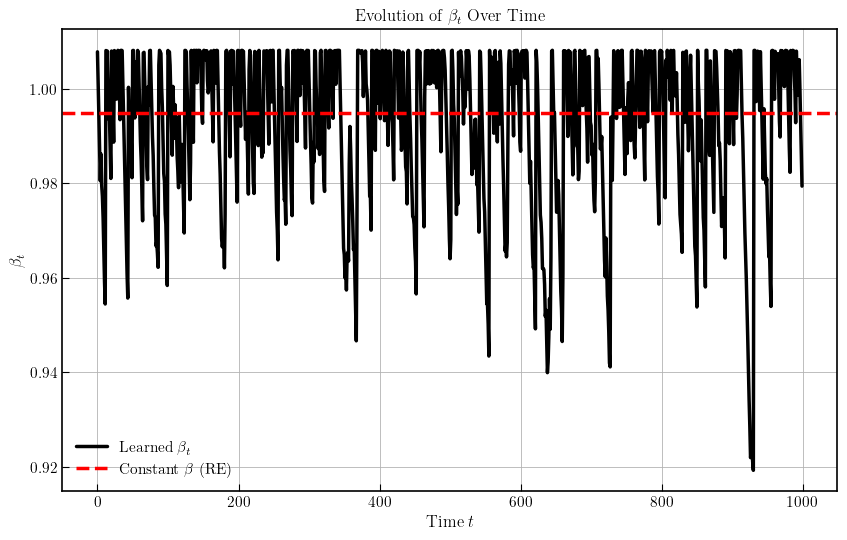

In [20]:
#plot the model beta and the constant beta for comparison
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(model.beta, label='Learned $\\beta_t$')
ax.axhline(y=model.beta_constant, color='r', linestyle='--', label='Constant $\\beta$ (RE)')
ax.set_title('Evolution of $\\beta_t$ Over Time')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$\\beta_t$') 
ax.legend()
plt.show()

In [21]:
model.beta[1], model.beta_constant, model.pd_ratio_u, model.pd_ratio_l

(np.float64(1.0006845277082124),
 np.float64(0.9948141398941047),
 np.float64(500.0000000000215),
 np.float64(250.0000000000037))

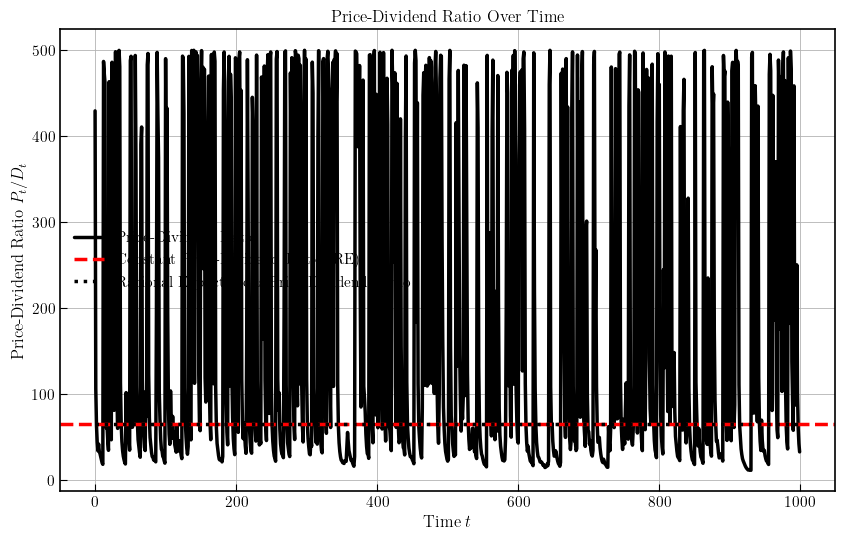

In [22]:
#visualize price to dividend ration
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(model.price / model.D, label='Price-Dividend Ratio')
#also plot the constant price dividend ratio for comparison as an horizontal line
ax.axhline(y=model.constant_price_dividend_ratio, color='r', linestyle='--', label='Constant Price-Dividend Ratio (RE)')
#add the rational expectations price dividend ratio
ax.plot(model.REE_price / model.D, label='Rational Expectations Price-Dividend Ratio', linestyle=':')
ax.set_title('Price-Dividend Ratio Over Time')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Price-Dividend Ratio $P_t / D_t$')
ax.legend()
plt.show()

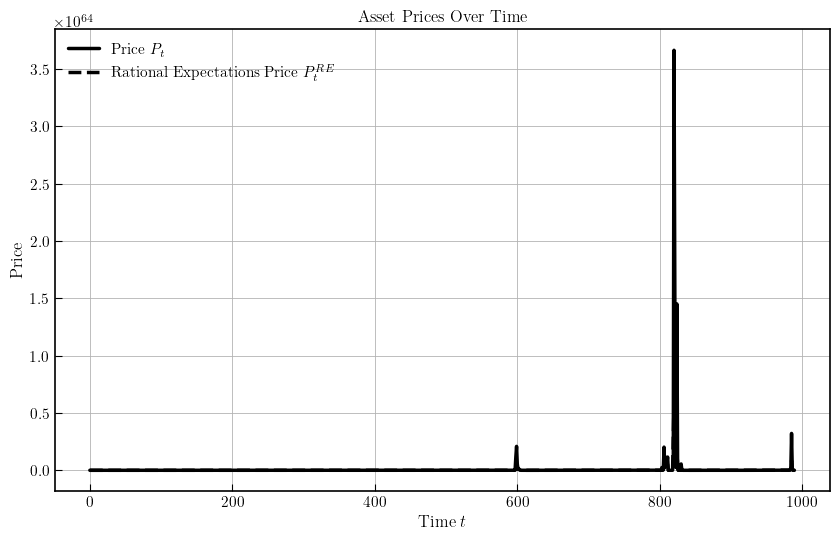

In [23]:
#visualize prices
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(model.price[10:], label='Price $P_t$')
ax.plot(model.REE_price[10:], label='Rational Expectations Price $P^{RE}_t$', linestyle='--')
ax.set_title('Asset Prices Over Time')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Price')
ax.legend()
plt.show()

In [24]:
#now let's visualize the distribution of returns in the model
model_returns = np.log(model.price / model.price_minus_1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(model_returns, bins=30, density=True, alpha=0.6, color='b')
ax.set_title('Distribution of Log Returns in the Adam-Marcet Model')
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
#overlay a normal distribution with same mean and std
from scipy.stats import norm
mu, std = norm.fit(model_returns)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.legend(['Fit results: $\mu$ = %.4f,  $\sigma$ = %.4f' % (mu, std)])
plt.show()

0.9948141398941047 0.005185860105895279 191.83204320594788 2.2038461448840847


In [ ]:
beta_constant = 109.50/109.50
#define rho_e a s a function of s_d to back out the value of s_d that gives us the empirical price dividend ratio
def rho_e_func(s_d):
    s_c = s_d / 7
    rho_e = np.exp(gamma * (1 + gamma) * s_c**2 / 2) * np.exp( - gamma * rho_c * s_c * s_d)
    return rho_e

#solve for rho_e = beta_constant / delta
from scipy.optimize import root_scalar
def equation(s_d):
    return rho_e_func(s_d) - beta_constant / (delta * a ** (1 - gamma))

solution = root_scalar(equation, bracket=[0.01, 10], method='bisect')
s_d_solution = solution.root
# s_c_solution = s_d_solution / 7
print("Solved s_d:", s_d_solution, "Solved s_c:", s_c_solution)
# print("rho_e at solution:", rho_e_func(s_d_solution))

Solved s_d: 2.2072258695610723 Solved s_c: 0.19576153183047443


In [ ]:
class Adam_Marcet_model_OLS:
    def __init__(self, parameters):
        self.a = parameters['a']
        self.s_dividend = parameters['s_dividend']
        self.s_consumption = parameters['s_consumption']
        self.rho_c = parameters['rho_c']
        self.delta = parameters['delta']
        self.gamma = parameters['gamma']
        self.alpha = parameters['alpha'] #gain parameter for learning (1/alpha) in the paper
        self.rho_e = np.exp(self.gamma * (1 + self.gamma) * self.s_consumption**2 / 2) * np.exp( - self.gamma * self.rho_c * self.s_consumption * self.s_dividend)
        self.seed = parameters.get('seed', None)
        if self.seed is not None:
            np.random.seed(self.seed)
        #bounds on beta
        self.beta_u =  (500 - self.delta * self.a ** (1 - self.gamma) * self.rho_e) / (500 * self.delta)
        self.beta_l = self.delta ** -1 - 2 * (self.delta ** -1 - self.beta_u)


        self.T = parameters['T']
        #X_t process
        self.X = np.random.normal(0, 1, self.T)

        self.D0 = parameters['D0']
        self.C0 = parameters['C0']
        self.D, self.C = np.zeros(self.T), np.zeros(self.T)
        self.beta = np.zeros(self.T)
        
        self.price = np.zeros(self.T)
        self.REE_price = np.zeros(self.T)

        #since to obtain beta_t we need beta_t-1, C_t-1 C_t-2 P_t-1 and P_t-2, we initialize them at their RE steady state value
        self.beta_constant = self.a ** (1 - self.gamma) * self.rho_e
        self.beta_minus_1 = self.a ** (1 - self.gamma) * self.rho_e
        self.C_minus_2 = 1 #arbitrary initial value
        self.C_minus_1 = self.a * np.exp(self.s_consumption**2 /2) * self.C_minus_2 #mean growth rate of consumption
        self.D_minus_2 = 1 #arbitrary initial value
        self.D_minus_1 = self.a * np.exp(self.s_dividend**2 /2) * self.D_minus_2 #mean growth rate of dividends
        self.price_minus_2 = (self.delta * self.beta_minus_1) / (1 - self.delta * self.beta_minus_1) * self.D_minus_2
        self.price_minus_1 = (self.delta * self.beta_minus_1) / (1 - self.delta * self.beta_minus_1) * self.D_minus_1

        self.constant_price_dividend_ratio = (self.delta * self.beta_constant) / (1 - self.delta * self.beta_constant)

        #implied bounds on price dividend ratio
        self.pd_ratio_u = (self.delta * self.beta_constant) / (1 - self.delta * self.beta_u)
        self.pd_ratio_l = (self.delta * self.beta_constant) / (1 - self.delta * self.beta_l)

    def weighting_function(self, x):
        #weighting function to rescale beta within bounds
        if x <= self.beta_l:
            return x
        else:
            return self.beta_l + (x - self.beta_l) / (x + self.beta_u - 2 * self.beta_l) * (self.beta_u - self.beta_l)



    def generate_exogenous_processes(self):
        # we generate the bivariate normal shocks with correlation rho_c and std dev s
        mean = [0, 0]
        cov = [[self.s_dividend**2, self.rho_c * self.s_dividend * self.s_consumption], 
               [self.rho_c * self.s_dividend * self.s_consumption, self.s_consumption**2]]
        shocks = np.random.multivariate_normal(mean, cov, self.T)
        epsilon_D = np.exp(shocks[:, 0])
        epsilon_C = np.exp(shocks[:, 1])
        
        self.D = self.D0 * np.cumprod(self.a * epsilon_D)
        self.C = self.C0 * np.cumprod(self.a * epsilon_C)

    def compute_endogenous_processes(self):
        for t in range(self.T):
            #first we update beta_t
            self.beta[t] = self.beta_minus_1 + (self.alpha) * ((self.C_minus_1 / self.C_minus_2) ** (-self.gamma) * (self.price_minus_1 / self.price_minus_2) - self.beta_minus_1)
            # we rescale beta_t within bounds
            self.beta[t] = self.weighting_function(self.beta[t])
            #then we compute the price
            self.price[t] = (self.delta * self.beta_constant) / (1 - self.delta * self.beta[t]) * self.D[t]
            self.REE_price[t] = (self.delta * self.beta_constant) / (1 - self.delta * self.beta_constant) * self.D[t]
            #update lagged variables
            self.beta_minus_1 = self.beta[t]
            self.C_minus_2 = self.C_minus_1
            self.C_minus_1 = self.C[t]
            self.D_minus_2 = self.D_minus_1
            self.D_minus_1 = self.D[t]
            self.price_minus_2 = self.price_minus_1
            self.price_minus_1 = self.price[t]

np.float64(1.0000000000005038)

In [277]:
def price_dividend_given_gamma(gamma, a, avg_risk_free, rho_c, s_c, s_d):
    delta = (avg_risk_free * (a ** -gamma) * np.exp(gamma * (1 + gamma) * s_c**2 / 2))**(-1)
    rho_e = np.exp(gamma * (1 + gamma) * s_c**2 / 2) * np.exp( - gamma * rho_c * s_c * s_d)
    k = (delta * a ** (1 - gamma) * rho_e) / (1 - delta * a ** (1 - gamma) * rho_e)
    return k

def equation_gamma(gamma, target_pd_ratio, a, avg_risk_free, rho_c, s_c, s_d):
    pd_ratio = price_dividend_given_gamma(gamma, a, avg_risk_free, rho_c, s_c, s_d)
    return pd_ratio - target_pd_ratio


In [294]:
def calibrate_steady_state(price_series, dividend_series, risk_free_rate):

    #check that series have the same length
    if len(price_series) != len(dividend_series) or len(price_series) != len(risk_free_rate):
        raise ValueError("All input series must have the same length.")
    #check that the rsik free rate is gross (1 + r)
    if np.any(risk_free_rate < 1):
        raise ValueError("Risk free rate series must be in gross terms (1 + r).")

    #calculate the average price dividend ratio
    pd_ratio = np.mean(price_series / dividend_series)
    #calculate the average of the gross return and the variance
    gross_return = price_series[1:] / price_series[:-1] 
    gross_return_mean = np.mean(gross_return)
    gross_return_var = np.var(gross_return)
    # calculate the average of the risk free rate
    rf_mean = np.mean(risk_free_rate)

    #calibrate the parameters
    a = gross_return_mean
    sd_squared = np.log(gross_return_var / a**2 + 1)
    sd = np.sqrt(sd_squared)
    sc = sd / 7
    rho_c = 0.2

    #back out gamma from the price dividend ratio, we need a very precise root finder
    gamma = root_scalar(equation_gamma, args=(pd_ratio, a, rf_mean, rho_c, sc, sd), bracket=[0.01, 20], method='brentq', xtol=1e-12).root

    #beack out delta
    delta = 1 / rf_mean * (a ** gamma * np.exp(-gamma * (1 + gamma) * sc**2 / 2))

    return [a, sd, sc, rho_c, gamma, delta]

In [295]:
#check if the calibration works for the Adam-Marcet model with fixed parameters
parameters = {
    'a': 1.7,
    's_dividend': 1.0,
    's_consumption': 1.0 / 7,
    'rho_c': 0.2,
    'delta': 0.9,
    'gamma': 5,
    'T': 1000,
    'D0': 1,
    'C0': 1,
    'seed': 18,
    'alpha': 0.0072
}
np.exp(parameters['s_dividend']**2 /2)

model = Adam_Marcet_model(parameters)
model.generate_exogenous_processes()

In [296]:
price_dividend_given_gamma(model.gamma, model.a, risk_free, model.rho_c, model.s_consumption, model.s_dividend)

np.float64(0.14530218102251516)

In [297]:
dividends = model.D
prices = model.delta * model.beta_constant / (1 - model.delta * model.beta_constant) * dividends
risk_free = (model.delta * (model.a ** -model.gamma) * np.exp(model.gamma * (1 + model.gamma) * model.s_consumption**2 / 2))**(-1)
risk_free_series = np.full(model.T, risk_free)
price_dividen = prices / dividends



In [298]:
params = calibrate_steady_state(prices, dividends, risk_free_series)

In [299]:
calibrated_a, calibrated_sd, calibrated_sc, calibrated_rho_c, calibrated_gamma, calibrated_delta = params
print("Calibrated parameters vs original:")
print(f"a: {calibrated_a} vs {parameters['a']}")
print(f"s_d: {calibrated_sd} vs {parameters['s_dividend']}")
print(f"s_c: {calibrated_sc} vs {parameters['s_consumption']}")
print(f"rho_c: {calibrated_rho_c} vs {parameters['rho_c']}")
print(f"gamma: {calibrated_gamma} vs {parameters['gamma']}")
print(f"delta: {calibrated_delta} vs {parameters['delta']}")

Calibrated parameters vs original:
a: 1.6960341175547133 vs 1.7
s_d: 0.9918260009689808 vs 1.0
s_c: 0.1416894287098544 vs 0.14285714285714285
rho_c: 0.2 vs 0.2
gamma: 4.999654382525653 vs 5
delta: 0.8938664559997808 vs 0.9


In [300]:
delta = 0.9
a = 1.1
gamma = 5
sigma_u = 0.1
kappa = delta * a ** (-gamma) * np.exp(sigma_u**2 / 2)
print(-kappa/(1 - kappa))

-1.281179736969276
